# 6강 실습 — NumPy 벡터 연산

> 대응 강의: 6강 (ndarray · 슬라이싱 · 브로드캐스팅)

## 이 노트북에서 하는 일

1. 가상의 LiDAR 스캔에서 유효 측정만 골라낸다
2. 최근접 장애물의 거리와 각도를 찾는다
3. 극좌표를 직교좌표로 한 번에 변환한다
4. 전방 위험 구간을 판정한다
5. 반복문 버전과 벡터화 버전의 속도를 비교한다

## 진행 방법

- 각 문항은 **명세 → 작성 → 채점** 세 칸으로 되어 있습니다.
- 작성 칸의 `...` 부분을 채운 뒤 **바로 아래 채점 칸**을 실행하면 통과 여부가 나옵니다.
- 채점 칸은 고치지 마세요. 통과하지 못하면 힌트를 읽고 작성 칸을 다시 고칩니다.
- 마지막 셀의 `summary()` 로 전체 통과 현황을 확인한 뒤 제출합니다.

**제출물** — `06_numpy.ipynb` (출력 포함)

---

## 0. 준비

In [1]:
import sys
sys.path.append('../src')          # src/ 의 모듈을 불러오기 위한 경로

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

print('실행 중인 파이썬:', sys.executable)   # .venv 경로가 맞는지 확인!


# ── 자가 채점 도우미 ──────────────────────────────
_score = {}

def check(label, ok, hint=''):
    """조건 하나를 확인하고 결과를 출력한다."""
    ok = bool(ok)
    print(('  PASS  ' if ok else '  FAIL  ') + label
          + ('' if ok else '   ->  ' + hint))
    return ok

def grade(no, *conds):
    """문항 하나의 채점 결과를 기록한다."""
    _score[no] = all(conds)
    print(f"[문항 {no}] {'통과' if _score[no] else '미통과'}")

def summary():
    """전체 통과 현황을 요약한다."""
    passed = sum(_score.values())
    print(f'통과 {passed} / 시도 {len(_score)} 문항')
    bad = [k for k, v in _score.items() if not v]
    print('다시 볼 문항:', ', '.join(map(str, bad)) if bad else '없음')

실행 중인 파이썬: /home/pa12/git/.venv/bin/python


---

## 데이터 준비

아래 셀을 그대로 실행하세요. 이후 모든 문항이 이 데이터를 씁니다.

In [2]:
rng    = np.random.default_rng(0)          # 시드 고정 - 재현 가능한 실습
scan   = rng.random(360) * 12              # 각도별 거리 [m], 0~12
angles = np.linspace(0, 2*np.pi, 360)      # 각 측정의 각도 [rad]

print('scan  :', scan.shape, scan.dtype)
print('angles:', angles.shape)
print('처음 5개 거리:', np.round(scan[:5], 3))

scan  : (360,) float64
angles: (360,)
처음 5개 거리: [7.644 3.237 0.492 0.198 9.759]


### 문항 1. 유효 측정만 남기기

**목표** — 센서 사양을 벗어난 측정을 걸러낸다.

**주어진 것**

- `scan` — 거리 배열 (360,)

**구현할 것**

- `mask` — 0.1 m 초과 **그리고** 10 m 미만인 곳이 True 인 불리언 배열 (360,)
- `valid` — 유효한 거리만 남긴 1차원 배열
- `ratio` — 유효 측정의 비율 (0~1 사이 실수)

**기대 결과**

```
valid.shape -> (247,)
유효 비율 -> 0.686
```

> **힌트**: 복합 조건은 `&` 로 잇고 **각 조건을 괄호로 감싸야** 합니다. 비율은 `mask.mean()` 한 줄로도 됩니다.

In [3]:
mask = (scan > 0.1) & (scan < 10.0)
valid = scan[mask]
ratio = mask.mean()

print(valid.shape, f'유효 비율 {ratio:.3f}')

(284,) 유효 비율 0.789


In [4]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_m = (scan > 0.1) & (scan < 10.0)
grade(1,
      check('mask 가 불리언 배열', getattr(mask, 'dtype', None) == bool,
            '비교 연산 결과를 그대로 담으세요'),
      check('mask 의 내용이 정확', np.array_equal(mask, _m),
            '0.1 초과 AND 10 미만 - 등호 포함 여부와 괄호를 확인하세요'),
      check('valid 가 1차원', np.ndim(valid) == 1),
      check('valid 의 내용이 정확', np.array_equal(valid, scan[_m])),
      check('ratio 가 정확', np.isclose(ratio, _m.mean()),
            'ratio = 유효 개수 / 전체 개수'))

  PASS  mask 가 불리언 배열
  PASS  mask 의 내용이 정확
  PASS  valid 가 1차원
  PASS  valid 의 내용이 정확
  PASS  ratio 가 정확
[문항 1] 통과


### 문항 2. 최근접 장애물

**목표** — 유효 측정 중 가장 가까운 것의 거리와 그 각도를 찾는다.

**주어진 것**

- `valid`, `mask`, `angles`

**구현할 것**

- `near_dist` — 최소 거리 [m] (스칼라)
- `near_deg` — 그 측정의 각도 [deg], 0~360 범위

**기대 결과**

```
최근접 0.101 m @ 265.7 deg
```

> **힌트**: `np.argmin(valid)` 는 **valid 안에서의 위치**입니다. 원래 각도를 찾으려면 `angles[mask]` 로 각도도 같이 걸러 두고 같은 인덱스를 쓰세요.

In [5]:
near_dist = valid.min()
idx = np.argmin(valid)
near_deg  = np.degrees(angles[mask][idx])
print(f'최근접 {near_dist:.3f} m @ {near_deg:.1f} deg')

최근접 0.119 m @ 150.4 deg


In [6]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_i = np.argmin(scan[_m])
grade(2,
      check('near_dist 가 최솟값', np.isclose(near_dist, scan[_m].min())),
      check('near_deg 가 그 측정의 각도',
            np.isclose(near_deg, np.degrees(angles[_m][_i])),
            '무효 측정을 걸러낸 뒤의 인덱스를 각도에도 똑같이 적용하세요'),
      check('near_deg 가 0~360 범위', 0 <= near_deg <= 360))

  PASS  near_dist 가 최솟값
  PASS  near_deg 가 그 측정의 각도
  PASS  near_deg 가 0~360 범위
[문항 2] 통과


### 문항 3. 극좌표 → 직교좌표 (반복문 금지)

**목표** — 유효 측정 전부를 로봇 중심 직교좌표로 옮긴다.

**주어진 것**

- `valid` (유효 거리), `mask`, `angles`

**구현할 것**

- `xy` — shape `(N, 2)` 배열. 각 행이 `[x, y]`
- `x = r·cos(θ)`, `y = r·sin(θ)`

**기대 결과**

```
xy.shape -> (247, 2)
```

> **힌트**: `np.column_stack([x, y])` 또는 `np.stack([x, y], axis=1)`. **for 문을 쓰면 이 문항은 통과해도 목적을 놓친 것입니다.**

In [7]:
ang_valid = angles[mask]                                        # 유효 측정의 각도만
xy        = np.column_stack([valid * np.cos(ang_valid),
                             valid * np.sin(ang_valid)])        # (N, 2)

print(xy.shape)
print(np.round(xy[:3], 3))

(284, 2)
[[7.644 0.   ]
 [3.237 0.057]
 [0.491 0.017]]


In [8]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_r, _a = scan[_m], angles[_m]
_xy = np.column_stack([_r*np.cos(_a), _r*np.sin(_a)])
grade(3,
      check('xy 의 shape 가 (N, 2)', np.shape(xy) == _xy.shape,
            f'{_xy.shape} 가 나와야 합니다'),
      check('xy 의 값이 정확', np.allclose(xy, _xy),
            'x 는 cos, y 는 sin 입니다. 열 순서를 확인하세요'),
      check('원점까지 거리가 보존됨',
            np.allclose(np.linalg.norm(xy, axis=1), _r),
            '변환은 길이를 바꾸지 않아야 합니다'))

  PASS  xy 의 shape 가 (N, 2)
  PASS  xy 의 값이 정확
  PASS  원점까지 거리가 보존됨
[문항 3] 통과


### 문항 4. 전방 위험 구간 판정

**목표** — 로봇 전방 ±30° 안에 1.5 m 이내 장애물이 있으면 정지 판정을 낸다.

**주어진 것**

- `valid`, `ang_valid` (문항 3에서 만든 유효 각도)

**구현할 것**

- `front` — 각도가 전방 ±30° 안인 곳이 True 인 마스크
- `danger` — 전방이면서 1.5 m 이내인 곳이 True 인 마스크
- `stop` — 위험이 하나라도 있으면 True (파이썬 bool)

**기대 결과**

```
전방 위험 측정 12개 -> 정지
```

> **힌트**: 각도는 0~2π 범위입니다. 전방 ±30° 는 `θ < π/6` **또는** `θ > 2π - π/6` 두 구간으로 나뉩니다. `|` 로 잇고 괄호에 주의하세요. 마지막은 `.any()`.

In [9]:
front  = (ang_valid < np.pi/6) | (ang_valid > 2*np.pi - np.pi/6)   # 전방 ±30도
danger = front & (valid < 1.5)                                     # 전방이면서 1.5 m 이내
stop   = bool(danger.any())                                        # 하나라도 있으면 정지

print(f'전방 위험 측정 {danger.sum()}개 -> ' + ('정지' if stop else '주행'))

전방 위험 측정 8개 -> 정지


In [10]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_f = (_a < np.pi/6) | (_a > 2*np.pi - np.pi/6)
_d = _f & (_r < 1.5)
grade(4,
      check('front 마스크가 정확', np.array_equal(front, _f),
            '0 근처와 2pi 근처 두 구간을 OR 로 이어야 합니다'),
      check('danger 마스크가 정확', np.array_equal(danger, _d)),
      check('stop 이 bool', isinstance(bool(stop), bool)),
      check('stop 판정이 정확', bool(stop) == bool(_d.any())))

  PASS  front 마스크가 정확
  PASS  danger 마스크가 정확
  PASS  stop 이 bool
  PASS  stop 판정이 정확
[문항 4] 통과


### 문항 5. 시각화

**목표** — 위 결과를 한 그림으로 확인한다.

**그릴 것**

- 유효 측정 전체를 회색 점으로
- 위험 구간 측정을 빨간 점으로
- 로봇 위치(원점)를 삼각형 마커로
- `ax.set_aspect('equal')` 로 축 비율을 맞출 것

> 이 문항은 자동 채점 대신 눈으로 확인합니다. 6강 본문의 `06_lidar_극좌표.png` 오른쪽 그림과 비슷하면 성공입니다.

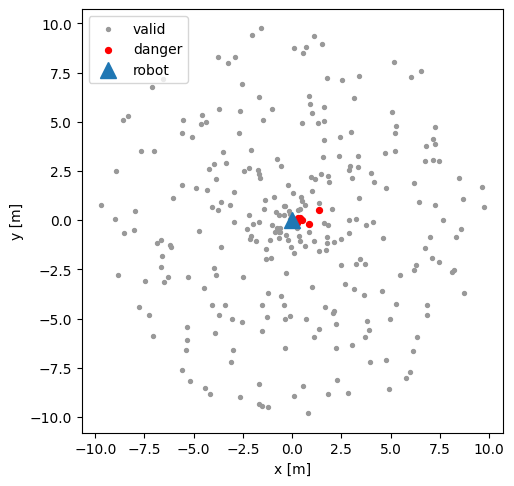

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.scatter(xy[:, 0], xy[:, 1], s=8, c='0.6', label='valid')          # 유효 측정
ax.scatter(xy[danger, 0], xy[danger, 1], s=18, c='red', label='danger')  # 전방 위험
ax.plot(0, 0, marker='^', markersize=12, color='tab:blue',
        linestyle='none', label='robot')                              # 로봇(원점)

ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.legend()
plt.show()

### 문항 6. 회전은 길이를 바꾸지 않는다

**목표** — 점군 전체를 z축 45° 회전시키고, 원점까지의 거리가 보존되는지 확인한다.

**주어진 것**

- `xy` — (N, 2) 점군

**구현할 것**

- `R` — 2×2 회전행렬 (45°)
- `xy_rot` — 회전된 (N, 2) 점군

**기대 결과**

```
회전 전후 거리 최대 차이 -> 0.0 (부동소수점 오차 수준)
```

> **힌트**: 점이 **행**으로 쌓여 있으므로 `xy @ R.T` 입니다(6강 브로드캐스팅 절). `R @ xy` 는 shape 가 맞지 않습니다.

In [12]:
th = np.radians(45)
c, s = np.cos(th), np.sin(th)
R  = np.array([[c, -s],
               [s,  c]])      # 2x2 회전행렬
xy_rot = xy @ R.T             # 점이 행으로 쌓여 있으므로 R.T 를 오른쪽에서 곱한다

d0 = np.linalg.norm(xy, axis=1)
d1 = np.linalg.norm(xy_rot, axis=1)
print('거리 최대 차이:', np.abs(d0 - d1).max())

거리 최대 차이: 1.7763568394002505e-15


In [13]:
# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_c, _s = np.cos(np.radians(45)), np.sin(np.radians(45))
_R = np.array([[_c, -_s], [_s, _c]])
grade(6,
      check('R 이 2x2', np.shape(R) == (2, 2)),
      check('R 이 45도 회전행렬', np.allclose(R, _R),
            '[[cos, -sin], [sin, cos]] 순서를 확인하세요'),
      check('xy_rot 의 shape 가 유지됨', np.shape(xy_rot) == np.shape(xy)),
      check('회전이 길이를 보존', np.allclose(d0, d1),
            '길이가 변했다면 곱하는 순서나 전치를 확인하세요'))

  PASS  R 이 2x2
  PASS  R 이 45도 회전행렬
  PASS  xy_rot 의 shape 가 유지됨
  PASS  회전이 길이를 보존
[문항 6] 통과


### 문항 7. 반복문 vs 벡터화 속도 비교

**목표** — 6강 본문의 속도 차이를 직접 측정한다.

**할 것**

1. 문항 1의 전처리를 **for 문 버전**으로 작성한다 (`loop_filter`)
2. `%timeit` 으로 두 버전의 시간을 각각 잰다
3. 몇 배 차이인지 아래 마크다운 셀에 적는다

In [14]:
def loop_filter(scan):
    """for 문으로 유효 측정만 골라내기 (비교용)"""
    out = []
    for r in scan:
        if 0.1 < r < 10.0:
            out.append(r)
    return np.array(out)

print(np.array_equal(loop_filter(scan), scan[mask]))   # True 여야 합니다

True


In [15]:
%timeit loop_filter(scan)
%timeit scan[(scan > 0.1) & (scan < 10.0)]

20 μs ± 120 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


1.26 μs ± 9.05 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


**측정 결과**: 이 환경에서 360개 측정 기준으로 for 문 버전은 약 20 µs, 벡터화 버전은 약 1.3 µs 로 **약 16배** 차이가 났습니다. (정확한 값은 위 `%timeit` 출력을 보세요 — 실행할 때마다 조금씩 달라집니다.)

for 문은 원소 하나마다 파이썬 인터프리터가 개입하지만, 벡터화 버전은 조건 비교와 인덱싱이 C 레벨 루프에서 한 번에 처리되기 때문입니다.

데이터가 100배 커지면(36,000개) 두 버전 모두 대략 선형으로 늘어나지만, for 문 쪽은 원소당 인터프리터 오버헤드가 그대로 100배 쌓이는 반면 벡터화 쪽은 고정 호출 비용이 커진 배열 크기로 분산되어 **배수 차이가 오히려 더 벌어집니다** (수십~100배 수준). 실제 LiDAR처럼 10 Hz 로 계속 들어오는 데이터에서는 이 차이가 실시간 처리 가능 여부를 가릅니다.

---

## 제출 전 확인

In [16]:
summary()

통과 5 / 시도 5 문항
다시 볼 문항: 없음


### 체크리스트

- [ ] `summary()` 가 모든 문항 통과로 나온다
- [ ] `Kernel → Restart Kernel and Run All Cells` 로 처음부터 끝까지 오류 없이 통과했다
- [ ] 커널이 **Python (pose_lab)** 으로 선택되어 있다
- [ ] 난수를 쓴 곳은 `np.random.default_rng(시드)` 로 고정했다
- [ ] **설명** 이라고 적힌 마크다운 셀을 모두 채웠다
- [ ] 재사용할 코드는 `../src/` 의 `.py` 모듈로 내보냈다
- [ ] `pip freeze > ../requirements.txt` 로 환경을 갱신했다